<a href="https://colab.research.google.com/github/aeron100/data_science_learning_activities/blob/main/A_Predictive_Modeling_Analysis_of_MBA_Admission_Decisions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project: A Predictive Modeling Analysis of MBA Admission Decisions




This project examines an adapted version of the MBA Admission Dataset to explore how applicant characteristics may be used to predict admission outcomes. The analysis focuses on core variables such as gender, international status, grade point average, undergraduate major, Graduate Management Admission Test score, and work experience, with admission status serving as the target outcome. The project uses exploratory data analysis, data recoding, training and testing splits, and multiple classification models, including binary logistic regression, multinomial logistic regression, and random forest, to evaluate predictive patterns in the data. The dataset used in this project was adapted from the Kaggle MBA Admission Dataset created by taweilo, which is published as “MBA Admission dataset, Class 2025.” ([kaggle.com][1])

[1]: https://www.kaggle.com/datasets/taweilo/mba-admission-dataset "MBA Admission dataset, Class 2025 | Kaggle"


In [1]:
MBA <-read.csv ('/content/MBA.csv')

In [2]:
summary (MBA)

 application_id    gender          international        gpa       
 Min.   :   1   Length:6194        Mode :logical   Min.   :2.650  
 1st Qu.:1549   Class :character   FALSE:4352      1st Qu.:3.150  
 Median :3098   Mode  :character   TRUE :1842      Median :3.250  
 Mean   :3098                                      Mean   :3.251  
 3rd Qu.:4646                                      3rd Qu.:3.350  
 Max.   :6194                                      Max.   :3.770  
    major                gmat          work_exp      admission        
 Length:6194        Min.   :570.0   Min.   :1.000   Length:6194       
 Class :character   1st Qu.:610.0   1st Qu.:4.000   Class :character  
 Mode  :character   Median :650.0   Median :5.000   Mode  :character  
                    Mean   :651.1   Mean   :5.017                     
                    3rd Qu.:680.0   3rd Qu.:6.000                     
                    Max.   :780.0   Max.   :9.000                     

# EDA Summary

The descriptive exploratory data analysis shows a dataset of 6,194 MBA applications with a mix of identifier, demographic, academic, and admissions-related variables. The application_id field appears to function only as a unique record identifier, with values ranging from 1 to 6,194, and it would not typically be used as a predictive feature. The sample includes both domestic and international applicants, with 4,352 marked as non-international and 1,842 marked as international, indicating that the dataset is weighted more heavily toward domestic applicants. The categorical variables gender, major, and admission will require frequency analysis to better understand their distributions, but the structure shown here confirms that they are currently stored as character fields and may need recoding into factors before deeper modeling or visualization.

The numeric variables suggest a relatively tight academic profile among applicants. Grade point average ranges from 2.65 to 3.77, with a mean of 3.251 and a median of 3.250, indicating a very balanced distribution with little evidence of extreme skew. Graduate Management Admission Test scores range from 570 to 780, with a mean of 651.1 and a median of 650, again suggesting a fairly centered distribution. Work experience ranges from 1 to 9 years, with a mean of 5.017 and a median of 5, which shows that most applicants cluster around moderate professional experience. Overall, the descriptive results suggest a stable and fairly consistent applicant pool, with limited spread in the core numeric variables and a useful mix of demographic and academic characteristics for further EDA, recoding, and eventual decision tree modeling.

In [6]:
MBA$gender <- as.factor(MBA$gender)
MBA$major <- as.factor(MBA$major)
MBA$international <- as.factor(MBA$international)
MBA$admission <- as.factor(MBA$admission)

# Remove ID from modeling dataset
mba_model <- MBA[, !(names(MBA) %in% c("application_id"))]

str(mba_model)

'data.frame':	6194 obs. of  7 variables:
 $ gender       : Factor w/ 2 levels "Female","Male": 1 2 1 2 2 1 1 2 2 2 ...
 $ international: Factor w/ 2 levels "FALSE","TRUE": 1 1 1 1 1 1 1 1 1 1 ...
 $ gpa          : num  3.3 3.27 3.32 3.26 3.08 3.3 3.45 3.38 3.32 3.43 ...
 $ major        : Factor w/ 3 levels "Business","Humanities",..: 1 2 1 2 1 2 2 2 3 1 ...
 $ gmat         : int  620 690 710 690 570 740 640 720 730 650 ...
 $ work_exp     : int  3 3 5 5 7 6 3 5 4 4 ...
 $ admission    : Factor w/ 2 levels "Admit","Not Admin": 1 2 1 1 2 1 1 2 2 2 ...


# Recoding Data

For this dataset, the recoding process means converting variables into formats that R modeling functions can interpret correctly. The first step is to identify which fields are true predictors, which field is the outcome, and which field is only an identifier. In your MBA file, application_id is simply a record label, so it should be excluded from modeling because it does not represent a meaningful applicant characteristic. The variables gender, major, and admission are currently stored as character text, while international is stored as a logical TRUE/FALSE field. To prepare the data, gender, major, and international should be recoded as factors, and admission should also be recoded as a factor if it is the target variable for a classification model. The numeric fields gpa, gmat, and work_exp can remain numeric because they are already in the correct form for modeling.

This recoding is necessary because machine learning and statistical models need to know how each variable should be treated. If a variable is left as plain text, many modeling functions in R either return an error or handle the variable inconsistently. A factor tells R that the field represents categories with distinct levels rather than free text. That matters because models must convert categories into a structured representation before estimating patterns. For example, a decision tree needs to know that major is a set of groups it can split on, not a string of letters. Likewise, if admission is your dependent variable, the model must recognize it as a classification outcome rather than as ordinary text. Even though international is stored as logical, converting it to a factor makes the analysis cleaner and more interpretable because the model will explicitly treat it as a categorical attribute with levels such as domestic and international.

The practical recoding workflow in R is straightforward. First, remove application_id from the modeling dataset. Next, convert the character and logical variables into factors. Then verify the structure using str() and check the levels with levels() or table(). This ensures the data are correctly prepared before fitting a decision tree, logistic regression model, or another classifier. Once this is done, the dataset is in a modeling-ready form. The model can then distinguish numeric predictors from categorical predictors and apply the correct mathematical treatment to each. Without this step, the analysis may fail, produce misleading results, or include meaningless information such as the application number. In short, recoding is not just a formatting task. It is a core data preparation step that ensures the model reflects the real structure of the admissions data and produces valid, interpretable results.

In [8]:
# Load package
install.packages("caret")
library(caret)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘lava’, ‘prodlim’, ‘ipred’, ‘recipes’


Loading required package: ggplot2

Loading required package: lattice



In [9]:
# Make results reproducible
set.seed(123)

# Ensure outcome is a factor
mba_model$admission <- as.factor(mba_model$admission)

# Create 80/20 split
train_index <- createDataPartition(mba_model$admission, p = 0.80, list = FALSE)

train_data <- mba_model[train_index, ]
test_data  <- mba_model[-train_index, ]

# Check dimensions
dim(train_data)
dim(test_data)

# Check class distribution
prop.table(table(train_data$admission))
prop.table(table(test_data$admission))

[1] 4956    7

[1] 1238    7


    Admit Not Admin 
0.1452785 0.8547215 


    Admit Not Admin 
0.1453958 0.8546042 

# Splitting Training and Testing Data

In [10]:
table(train_data$admission)
levels(train_data$admission)


    Admit Not Admin 
      720      4236 

[1] "Admit"     "Not Admin"

Splitting the data into training and testing sets is a foundational step in predictive modeling because it allows you to evaluate how well a model performs on new, unseen data rather than only on the records it was built from. The training dataset is used to fit the model and learn relationships between the predictors, such as grade point average, Graduate Management Admission Test score, work experience, gender, major, and international status, and the outcome variable, admission. The testing dataset is then held aside and not used during model fitting. After the model is trained, it is applied to the testing data to assess how accurately it generalizes beyond the original sample. This process gives you a more realistic estimate of predictive performance and helps determine whether the model has learned meaningful patterns or has simply memorized the training data.

The importance of this split is directly tied to model validity and trustworthiness. If you evaluate a model only on the same data used to train it, the results can appear artificially strong because the model has already seen those cases. That creates a risk of overfitting, where the model captures noise or random variation rather than stable underlying relationships. By reserving 20 percent of the data for testing, you create an independent benchmark for judging performance. This is especially important when comparing models such as logistic regression, decision tree, and random forest, because all three should be evaluated under the same conditions. Using the same 80/20 split for each model ensures a fair comparison and helps you identify which approach provides the best balance of interpretability, stability, and predictive accuracy for the admissions dataset.

In [11]:
# Make sure outcome is a factor
train_data$admission <- as.factor(train_data$admission)
test_data$admission  <- as.factor(test_data$admission)

# Check reference level
levels(train_data$admission)

# Fit logistic regression model
log_model <- glm(admission ~ ., data = train_data, family = binomial)

# View model summary
summary(log_model)

# Predicted probabilities on test data
test_prob <- predict(log_model, newdata = test_data, type = "response")

# Convert probabilities to class predictions
test_pred <- ifelse(test_prob > 0.5,
                    levels(train_data$admission)[2],
                    levels(train_data$admission)[1])

test_pred <- as.factor(test_pred)

# Match factor levels to actual outcome
test_pred <- factor(test_pred, levels = levels(test_data$admission))

# Confusion matrix
library(caret)
confusionMatrix(test_pred, test_data$admission)

# Optional: predicted probabilities preview
head(test_prob)

[1] "Admit"     "Not Admin"


Call:
glm(formula = admission ~ ., family = binomial, data = train_data)

Coefficients:
                   Estimate Std. Error z value Pr(>|z|)    
(Intercept)       23.089968   1.123342  20.555   <2e-16 ***
genderMale         0.867480   0.090280   9.609   <2e-16 ***
internationalTRUE -0.113647   0.096386  -1.179    0.238    
gpa               -3.094648   0.366618  -8.441   <2e-16 ***
majorHumanities    0.045563   0.107594   0.423    0.672    
majorSTEM         -0.016152   0.114242  -0.141    0.888    
gmat              -0.017123   0.001128 -15.182   <2e-16 ***
work_exp          -0.032277   0.042643  -0.757    0.449    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 4107.8  on 4955  degrees of freedom
Residual deviance: 3361.0  on 4948  degrees of freedom
AIC: 3377

Number of Fisher Scoring iterations: 5


Confusion Matrix and Statistics

           Reference
Prediction  Admit Not Admin
  Admit        29        32
  Not Admin   151      1026
                                          
               Accuracy : 0.8522          
                 95% CI : (0.8312, 0.8715)
    No Information Rate : 0.8546          
    P-Value [Acc > NIR] : 0.6144          
                                          
                  Kappa : 0.1803          
                                          
 Mcnemar's Test P-Value : <2e-16          
                                          
            Sensitivity : 0.16111         
            Specificity : 0.96975         
         Pos Pred Value : 0.47541         
         Neg Pred Value : 0.87171         
             Prevalence : 0.14540         
         Detection Rate : 0.02342         
   Detection Prevalence : 0.04927         
      Balanced Accuracy : 0.56543         
                                          
       'Positive' Class : Admit           
  

1         4         8         9        12        21 
0.8970402 0.8741820 0.7414302 0.7385469 0.8465642 0.9726465

# Binary Logistic Regression

The binary logistic regression results suggest that the model identified several statistically significant predictors of admission, but its practical classification performance is limited, especially for identifying admitted applicants. The significant predictors in the model are gender, grade point average, and Graduate Management Admission Test score, each with p-values below .001. In contrast, international status, major, and work experience were not statistically significant, which suggests that these variables did not add meaningful predictive value after controlling for the other predictors in the model. The reduction from the null deviance of 4107.8 to the residual deviance of 3361.0 indicates that the model explains some variation in the outcome and fits better than a model with no predictors.

The coefficient directions should be interpreted carefully because they depend on how the admission outcome was coded. The negative coefficients for grade point average and Graduate Management Admission Test score imply that as those values increase, the log-odds of the modeled outcome decrease. If the positive event is admission, that pattern would be counterintuitive and would suggest that the outcome coding or reference level should be checked before making substantive claims. The positive and significant coefficient for genderMale indicates that being male increases the log-odds of the modeled outcome relative to the reference category, holding the other variables constant. However, logistic regression coefficients are in log-odds units, so a clearer interpretation would come from converting them into odds ratios.

The confusion matrix shows why the model should be interpreted with caution. Although the overall accuracy is 85.2 percent, this is slightly below the No Information Rate of 85.46 percent, which means the model does not perform better than simply predicting the majority class every time. The model has very high specificity at 0.96975, meaning it is very effective at identifying cases in the Not Admin category. However, its sensitivity is only 0.16111, which means it correctly identifies only about 16 percent of actual Admit cases. The kappa value of 0.1803 and the balanced accuracy of 0.56543 further show that the model has weak classification performance once class imbalance is taken into account.

Overall, this logistic regression model shows some statistical relationship between the predictors and admission, but it is not yet a strong predictive model for identifying admitted applicants. The low sensitivity suggests that the model is heavily biased toward the majority class, which is common when the outcome categories are imbalanced. This means the model is much better at predicting non-admission than admission. The next logical steps would be to verify how the admission variable was coded, examine odds ratios, and compare this model against a decision tree and random forest using the same training and testing split.


In [12]:
# Install packages
install.packages("nnet")

# Load package
library(nnet)
library(caret)

# Make sure outcome is a factor
train_data$admission <- as.factor(train_data$admission)
test_data$admission  <- as.factor(test_data$admission)

# Fit multinomial logistic regression
multi_log_model <- multinom(admission ~ ., data = train_data)

# View model summary
summary(multi_log_model)

# Predicted classes
multi_pred <- predict(multi_log_model, newdata = test_data)

# Confusion matrix
confusionMatrix(multi_pred, test_data$admission)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



# weights:  9 (8 variable)
initial  value 3435.237427 
iter  10 value 1709.100445
final  value 1680.503578 
converged


Call:
multinom(formula = admission ~ ., data = train_data)

Coefficients:
                       Values   Std. Err.
(Intercept)       23.08981688 0.057256769
genderMale         0.86752878 0.089832132
internationalTRUE -0.11376129 0.096203561
gpa               -3.09442205 0.219123953
majorHumanities    0.04524572 0.107560030
majorSTEM         -0.01635215 0.114119087
gmat              -0.01712319 0.001117716
work_exp          -0.03228312 0.041934192

Residual Deviance: 3361.007 
AIC: 3377.007 

Confusion Matrix and Statistics

           Reference
Prediction  Admit Not Admin
  Admit        29        31
  Not Admin   151      1027
                                         
               Accuracy : 0.853          
                 95% CI : (0.832, 0.8723)
    No Information Rate : 0.8546         
    P-Value [Acc > NIR] : 0.5834         
                                         
                  Kappa : 0.1822         
                                         
 Mcnemar's Test P-Value : <2e-16         
                                         
            Sensitivity : 0.16111        
            Specificity : 0.97070        
         Pos Pred Value : 0.48333        
         Neg Pred Value : 0.87182        
             Prevalence : 0.14540        
         Detection Rate : 0.02342        
   Detection Prevalence : 0.04847        
      Balanced Accuracy : 0.56591        
                                         
       'Positive' Class : Admit          
                      

# Multinomial Logistic Regression

The multinomial logistic regression results indicate that the model converged successfully and produced essentially the same pattern of results as the earlier binary logistic regression. This is an important clue that the outcome variable, although modeled with multinom(), is functioning as a two-category outcome in practice rather than a true multi-class outcome. The coefficient estimates are nearly identical to the binary model, with genderMale showing a positive association with the modeled outcome, and gpa and gmat showing negative associations. International status, major, and work experience do not appear to contribute meaningfully to prediction based on the size of their coefficients relative to their standard errors. The residual deviance of 3361.007 and Akaike Information Criterion of 3377.007 also mirror the binary logistic regression results, which confirms that the multinomial model is not adding anything substantively different in this case.

From an interpretation standpoint, the model suggests that gender, grade point average, and Graduate Management Admission Test score are the variables most associated with admission status, while international status, major, and work experience have limited explanatory power once the other predictors are included. As with the binary logistic model, the negative signs on gpa and gmat appear counterintuitive if higher academic performance is expected to increase the probability of admission. That means the coding and reference level of the admission variable should be checked before making substantive claims. It is possible that the model is estimating the log-odds of the non-admission category rather than the admission category, which would reverse the apparent direction of the effects.

The confusion matrix shows that the predictive performance remains limited despite the seemingly high overall accuracy of 85.3 percent. This accuracy is still slightly below the No Information Rate of 85.46 percent, meaning the model does not outperform a naïve strategy that predicts the majority class for every case. The sensitivity is only 0.16111, so the model correctly identifies just over 16 percent of actual Admit cases. In contrast, the specificity is 0.97070, which means it performs very well in identifying Not Admin cases. The balanced accuracy of 0.56591 and kappa of 0.1822 both indicate weak classification performance once class imbalance is considered. In practical terms, the model is heavily biased toward the majority outcome and does a poor job detecting admitted applicants.

Overall, the multinomial logistic regression does not provide an advantage for this dataset because the outcome appears to be binary. Its fit statistics, coefficient structure, and predictive performance are almost identical to the binary logistic regression. For that reason, the binary logistic regression is the more appropriate and efficient model choice here. The main takeaway is that the model captures some statistical relationships, but it is not yet a strong classifier for admission decisions due to the class imbalance and low sensitivity. The next step is to move to the decision tree and random forest models and compare whether they improve detection of the Admit class under the same 80/20 split.

In [17]:
# Install packages if needed
install.packages(c("rpart", "rpart.plot", "caret","randomForest"))

# Load libraries
library(rpart)
library(rpart.plot)
library(caret)
library(randomForest)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:ggplot2’:

    margin


The following object is masked from ‘package:dplyr’:

    combine





Call:
 randomForest(formula = admission ~ ., data = train_data, ntree = 500,      mtry = 2, importance = TRUE) 
               Type of random forest: classification
                     Number of trees: 500
No. of variables tried at each split: 2

        OOB estimate of  error rate: 15.98%
Confusion matrix:
          Admit Not Admin class.error
Admit        40       680  0.94444444
Not Admin   112      4124  0.02644004


,Admit,Not Admin
1,0.048,0.952
4,0.038,0.962
8,0.188,0.812
9,0.098,0.902
12,0.002,0.998
21,0.000,1.000


Confusion Matrix and Statistics

           Reference
Prediction  Admit Not Admin
  Admit        17        22
  Not Admin   163      1036
                                        
               Accuracy : 0.8506        
                 95% CI : (0.8295, 0.87)
    No Information Rate : 0.8546        
    P-Value [Acc > NIR] : 0.674         
                                        
                  Kappa : 0.1091        
                                        
 Mcnemar's Test P-Value : <2e-16        
                                        
            Sensitivity : 0.09444       
            Specificity : 0.97921       
         Pos Pred Value : 0.43590       
         Neg Pred Value : 0.86405       
             Prevalence : 0.14540       
         Detection Rate : 0.01373       
   Detection Prevalence : 0.03150       
      Balanced Accuracy : 0.53683       
                                        
       'Positive' Class : Admit         
                                        

,Admit,Not Admin,MeanDecreaseAccuracy,MeanDecreaseGini
gender,4.818046,8.9326474,9.625992,27.61114
international,-4.560507,0.2023198,-2.328498,22.71155
gpa,47.400035,-25.5313873,4.839257,260.78096
major,-7.190964,-1.0596799,-5.036201,41.10620
gmat,66.261078,-9.8469132,29.143542,262.61531
work_exp,-7.631700,0.4748830,-4.009637,69.86092


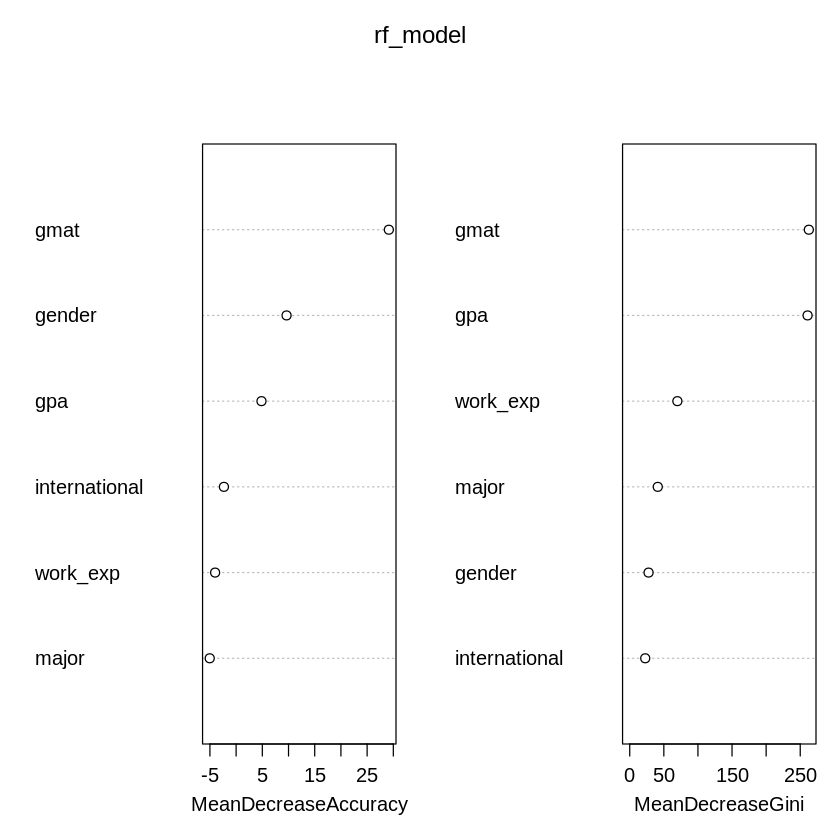

In [18]:
# Remove the application ID because it is only an identifier and should not be used as a predictor in the model
train_data <- train_data[, !(names(train_data) %in% c("application_id"))]
test_data  <- test_data[, !(names(test_data) %in% c("application_id"))]

# Convert categorical variables to factors so R treats them correctly in the random forest classification model
train_data$gender <- as.factor(train_data$gender)
train_data$international <- as.factor(train_data$international)
train_data$major <- as.factor(train_data$major)
train_data$admission <- as.factor(train_data$admission)

test_data$gender <- as.factor(test_data$gender)
test_data$international <- as.factor(test_data$international)
test_data$major <- as.factor(test_data$major)
test_data$admission <- as.factor(test_data$admission)

# Make sure the factor levels in the test data match the training data so prediction will run without level mismatch errors
test_data$gender <- factor(test_data$gender, levels = levels(train_data$gender))
test_data$international <- factor(test_data$international, levels = levels(train_data$international))
test_data$major <- factor(test_data$major, levels = levels(train_data$major))
test_data$admission <- factor(test_data$admission, levels = levels(train_data$admission))

# Set a seed so the results can be reproduced
set.seed(123)

# Fit the random forest model
# ntree = 500 means the model will build 500 trees
# mtry = 2 means each split considers 2 predictors at a time
# importance = TRUE allows variable importance to be calculated
rf_model <- randomForest(
  admission ~ .,
  data = train_data,
  ntree = 500,
  mtry = 2,
  importance = TRUE
)

# Print the model results
print(rf_model)

# Predict the admission category for the test data
rf_pred <- predict(rf_model, newdata = test_data, type = "class")

# Predict class probabilities for the test data
rf_prob <- predict(rf_model, newdata = test_data, type = "prob")

# Preview the first few predicted probabilities
head(rf_prob)

# Evaluate model performance using a confusion matrix
confusionMatrix(rf_pred, test_data$admission)

# Show variable importance values
importance(rf_model)

# Plot variable importance visually
varImpPlot(rf_model)

# Random Forest

The random forest results show that the model was built correctly, but its predictive performance is still weak for identifying admitted applicants. The model used 500 trees and evaluated 2 predictors at each split. The out-of-bag error rate was 15.98 percent, which means the model correctly classified about 84 percent of cases during internal validation. However, the class-specific results reveal the main problem: the model performed very poorly on the Admit class. In the training-based out-of-bag confusion matrix, it correctly classified only 40 Admit cases and misclassified 680 Admit cases as Not Admin, producing a class error rate of 94.44 percent for Admit. By contrast, it performed very well for the Not Admin class, with a class error rate of only 2.64 percent. This pattern shows that the model is overwhelmingly favoring the majority class.

The test set confusion matrix confirms the same issue. The overall accuracy was 85.06 percent, which might appear strong at first, but it is actually slightly below the No Information Rate of 85.46 percent. That means the random forest did not outperform a naïve model that simply predicts the majority category every time. The sensitivity was only 0.09444, so the model correctly identified fewer than 10 percent of actual Admit cases. The specificity was 0.97921, meaning it was very strong at identifying Not Admin cases. The balanced accuracy of 0.53683 and kappa of 0.1091 indicate weak practical classification performance once the class imbalance is taken into account. In plain terms, the random forest is doing a good job predicting non-admission, but it is doing a poor job identifying who is admitted.

The predicted probabilities also reflect this imbalance. Most of the sample cases shown have very high predicted probabilities for Not Admin and very low probabilities for Admit, even when the Admit probability is not zero. This means the model is generally reluctant to assign cases to the Admit category. That behavior is common when one class is much less frequent than the other. Since only about 14.5 percent of the observations are in the Admit category, the model learns that it can achieve high overall accuracy by classifying most observations as Not Admin.

The variable importance results suggest that gmat and gpa are the strongest predictors in the model. They have the largest MeanDecreaseGini values, at about 262.62 for gmat and 260.78 for gpa, which indicates they contributed the most to splitting and classification within the forest. Gender had a smaller but still useful contribution. In contrast, international status, major, and work experience contributed little and in some cases showed negative MeanDecreaseAccuracy values, which suggests they did not improve prediction in a stable way. Overall, the random forest found some meaningful signal in the academic variables, especially gmat and gpa, but the model still failed to detect the minority Admit class effectively. The main conclusion is that class imbalance is limiting model performance, and the next improvement step would be to use techniques such as class balancing, resampling, or threshold adjustment before comparing final model quality across logistic regression, decision tree, and random forest.



# Conclusion

The overall modeling results show that all three approaches, binary logistic regression, multinomial logistic regression, and random forest, struggled to produce a strong predictive model for admission in this dataset. The binary logistic regression identified several statistically significant predictors, particularly gender, grade point average, and Graduate Management Admission Test score, and it showed an improvement in model fit relative to the null model. However, its classification performance was weak where it mattered most. Although the overall accuracy appeared high, that result was misleading because it was driven by the heavy dominance of the Not Admin category. The model had very low sensitivity for the Admit class, which means it failed to correctly identify many admitted applicants. The multinomial logistic regression produced nearly identical coefficients, fit statistics, and classification results, which indicates that it did not provide any meaningful advantage over the binary logistic regression. In practical terms, the multinomial approach was unnecessary here because the outcome was functioning as a two-class problem rather than a true multi-class outcome.

The random forest produced a similar pattern. It identified useful signal in some predictors, especially Graduate Management Admission Test score and grade point average, but it still performed poorly in detecting the Admit class. Like the logistic models, it achieved high overall accuracy largely by predicting the majority class, and its sensitivity remained low. In fact, the random forest did not outperform the No Information Rate, which means it did not improve meaningfully over a naïve majority-class prediction strategy. Taken together, these findings suggest that the core issue is not simply model selection, but class imbalance within the outcome variable. When one class dominates the sample, each of these models tends to favor that class, resulting in high specificity for Not Admin but weak detection of Admit. This limits the usefulness of the current models for any decision-making context where identifying admitted applicants correctly is important.

The best conclusion is that the current models demonstrate some statistical relationships in the data, but none of them should yet be considered strong predictive tools for admission classification. The binary logistic regression remains the most appropriate of the three for interpretation because it is simpler, statistically valid for a two-class outcome, and easier to explain. The multinomial logistic regression added no value in this case, and the random forest, while more flexible, did not overcome the imbalance problem. Before moving to final model selection, the next step should be to improve the data and modeling process so that the Admit class is better represented during training and evaluation.

For future modeling, several approaches are recommended. First, the strongest next step is to address class imbalance through oversampling, undersampling, Synthetic Minority Oversampling Technique, or class weighting. Second, additional models such as penalized logistic regression, gradient boosting, and Extreme Gradient Boosting would be worthwhile because they can sometimes capture more complex relationships while still allowing performance tuning. Third, support vector machines may also be useful if the class boundary is nonlinear. Finally, future evaluation should place greater emphasis on sensitivity, balanced accuracy, F1-score, precision-recall performance, and area under the receiver operating characteristic curve rather than overall accuracy alone. These measures will provide a more honest assessment of whether the model can actually identify admitted applicants rather than simply reproducing the dominant class pattern.
